# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: 
- _Student No._: 20XX-XXXXX
- _Section_: THR-TX-X

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.


### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

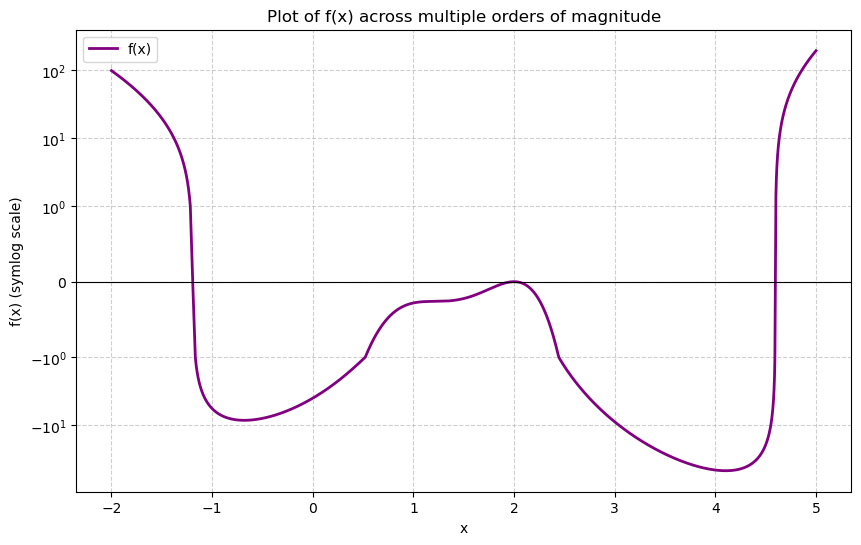

In [13]:

x = np.linspace(-2,5,100000)
func = -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

plt.figure(figsize=(10, 6))
plt.plot(x, func, color='purple', linewidth=2, label='f(x)')


plt.yscale('symlog', linthresh=1.0)


plt.title('Plot of f(x) across multiple orders of magnitude')
plt.xlabel('x')
plt.ylabel('f(x) (symlog scale)')
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()

plt.show()

In [31]:
import math

def fixedpoint(g, xold):
    for _ in range(100):
        xnew = g(xold)
        if abs(xnew - xold) < 1e-8: # Stop when guess stops changing
            return xnew
        xold = xnew
    else: 
        print("none")
    return xnew





def g1(x):
    return np.cbrt(np.exp(x) -2)


def g2(x):
    return np.log(x**3 + 2)


def g3(x):
    g_raw = -(-x**5 + 4*x**4 - 4*x**3 + x**2*math.exp(x) - 2*x**2 - 4*x*math.exp(x) + 4*math.exp(x) - 8) / 8
    return 0.5 * x + 0.5 * g_raw


# --- Find and Print All 3 Roots ---
r1 = fixedpoint(g1, xold=-2.0)
r2 = fixedpoint(g2, xold=4.0)
r3 = fixedpoint(g3, xold=2.5)

print(f"Root 1: {r1:.8f}")
print(f"Root 2: {r2:.8f}")
print(f"Root 3: {r3:.8f}")

none
Root 1: -1.19268577
Root 2: 4.59586355
Root 3: 1.91462925


In [36]:
# Bisection
import numpy as np

def fun(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

def bisection(f, x0, x1, kmax=200, tol=1.e-8):
    f0 = f(x0)
    for k in range(1, kmax):
        x2 = (x0 + x1) / 2
        f2 = f(x2)
        if f0 * f2 < 0:
            x1 = x2
        else:
            x0, f0 = x2, f2
        x2new = (x0 + x1) / 2
        xdiff = abs(x2new - x2)
                
        if abs(xdiff / x2new) < tol:
            break
    else:
        x2new = None
    return x2new

# Print the final root for each interval
print("Root in [-2, 0]:", bisection(fun, -2, 0))

print("Root in [3, 5] :", bisection(fun, 3, 5))

# The root at 2 cannot be obtained since the neighborhood of x-values around it has no opposite-signed pairs.

Root in [-2, 0]: -1.1926857605576515
Root in [3, 5] : 4.595863550901413


In [48]:
# Newton's Method 
import numpy as np


x = np.linspace(-2,5,100000)
def fN(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
def dfN(x): # analytically solved derivative
    return -5*x**4 + 16*x**3 + x**2*np.exp(x) - 12*x**2 - 2*x*np.exp(x) - 4*x + 8


def newton(f, df, x0, tol=1e-8, iter=200):
    x = float(x0)
    for _ in range(iter):
        fx = fN(x)
        dfx = dfN(x)
        if abs(fx/dfx) < tol:
            return x
        
        if dfx == 0:
            break
        x = x - fx / dfx
    return x


print("Root 1:", newton(fN, dfN, -1.0))  # -1.19268576...
print("Root 2:", newton(fN, dfN, 1.5))   #  2.00000000...
print("Root 3:", newton(fN, dfN, 4.0))   #  4.59586356...



Root 1: -1.1926857650226055
Root 2: 2.0000000154586135
Root 3: 1.9999999607344416


#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---